In [22]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/sales_data.csv")

df['date'] = pd.to_datetime(df['date'])

df.head()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/sales_data.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Show first rows
df.head()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/sales_data.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Show first rows
df.head()

,date,store,product,sales,price
0,2023-01-01,Store_1,Product_A,29,411.88
1,2023-01-02,Store_1,Product_A,27,338.74
2,2023-01-03,Store_1,Product_A,23,283.70
3,2023-01-04,Store_1,Product_A,25,233.48
4,2023-01-05,Store_1,Product_A,27,122.56


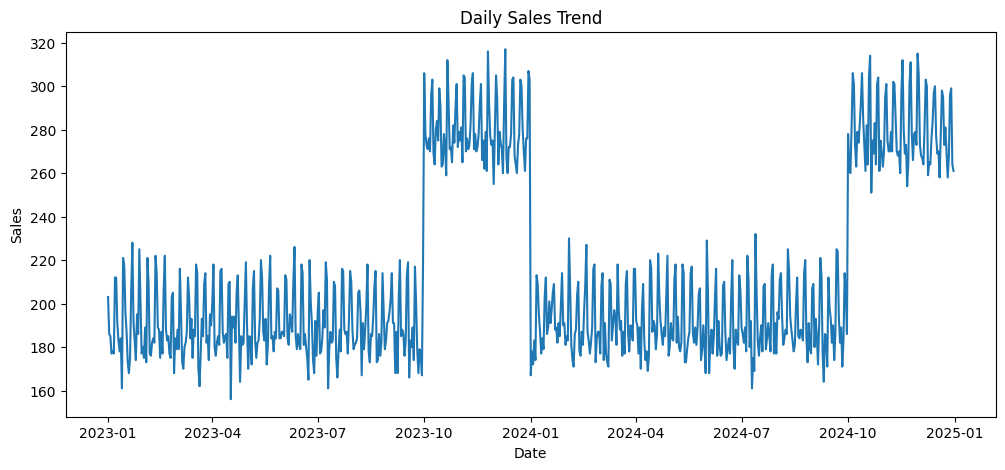

In [2]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

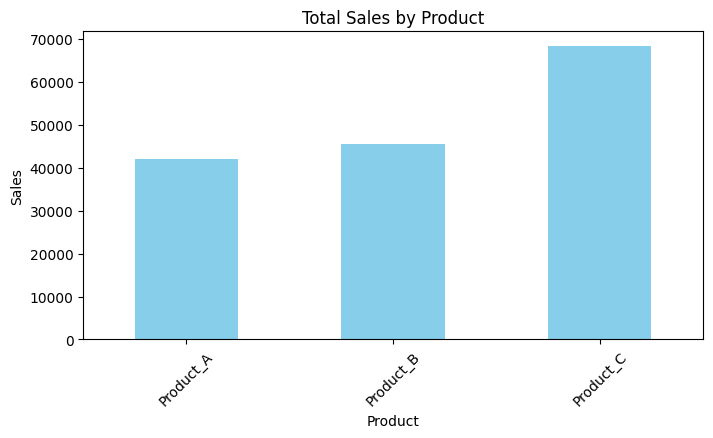

In [3]:
product_sales = df.groupby('product')['sales'].sum().sort_values()

plt.figure(figsize=(8,4))
product_sales.plot(kind='bar', color='skyblue')
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

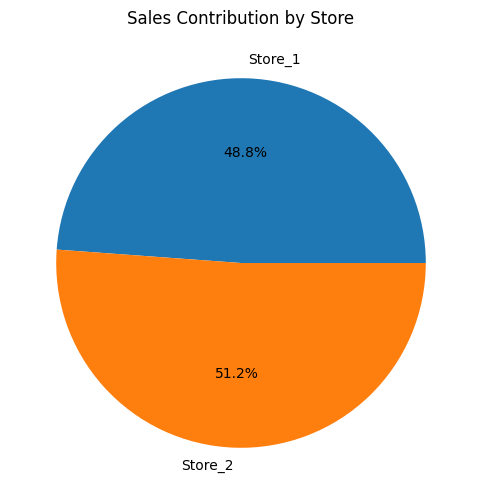

In [4]:
store_sales = df.groupby('store')['sales'].sum()

plt.figure(figsize=(6,6))
store_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Contribution by Store")
plt.ylabel("")
plt.show()

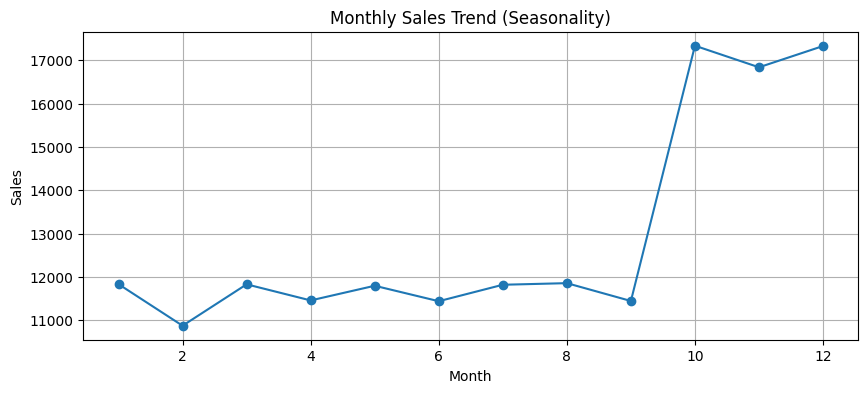

In [5]:
df['month'] = df['date'].dt.month

monthly_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(10,4))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

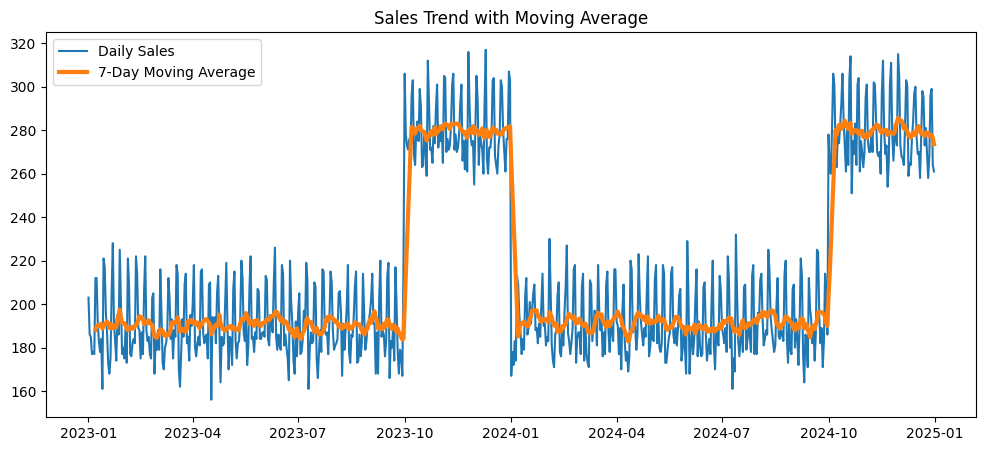

In [6]:
df_sorted = df.sort_values('date')

daily_sales = df_sorted.groupby('date')['sales'].sum()

moving_avg = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales, label="Daily Sales")
plt.plot(moving_avg, label="7-Day Moving Average", linewidth=3)
plt.legend()
plt.title("Sales Trend with Moving Average")
plt.show()

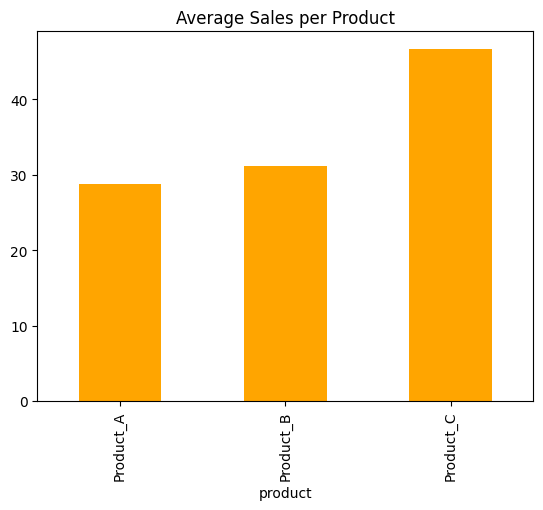

In [7]:
category_sales = df.groupby('product')['sales'].mean()

category_sales.plot(kind='bar', color='orange')
plt.title("Average Sales per Product")
plt.show()

In [8]:
df_forecast = df.groupby('date')['sales'].sum().reset_index()

df_forecast.columns = ['ds', 'y']  # Prophet format

df_forecast.head()

,ds,y
0,2023-01-01,203
1,2023-01-02,186
2,2023-01-03,185
3,2023-01-04,177
4,2023-01-05,178


In [9]:
from prophet import Prophet

ModuleNotFoundError: No module named 'prophet'

In [10]:
import sys
print(sys.executable)

c:\Users\Sakshi\AppData\Local\Programs\Python\Python312\python.exe


In [11]:
pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.94-py3-none-any.whl.metadata (52 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached holidays-0.94-py3-none-any.whl (1.4 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from prophet import Prophet
print("Prophet working!")

Importing plotly failed. Interactive plots will not work.


Prophet working!


In [13]:
df_forecast = df.groupby('date')['sales'].sum().reset_index()

df_forecast.columns = ['ds', 'y']

df_forecast.head()

,ds,y
0,2023-01-01,203
1,2023-01-02,186
2,2023-01-03,185
3,2023-01-04,177
4,2023-01-05,178


In [14]:
model = Prophet()
model.fit(df_forecast)

21:06:31 - cmdstanpy - INFO - Chain [1] start processing
21:06:32 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(periods=30)
future.tail()

,ds
756,2025-01-26
757,2025-01-27
758,2025-01-28
759,2025-01-29
760,2025-01-30


In [16]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
756,2025-01-26,222.072511,208.221445,236.498130
757,2025-01-27,192.458966,178.647754,207.868240
758,2025-01-28,193.454852,178.801954,208.880631
759,2025-01-29,194.490865,179.429585,209.268867
760,2025-01-30,196.492863,182.325421,212.224487


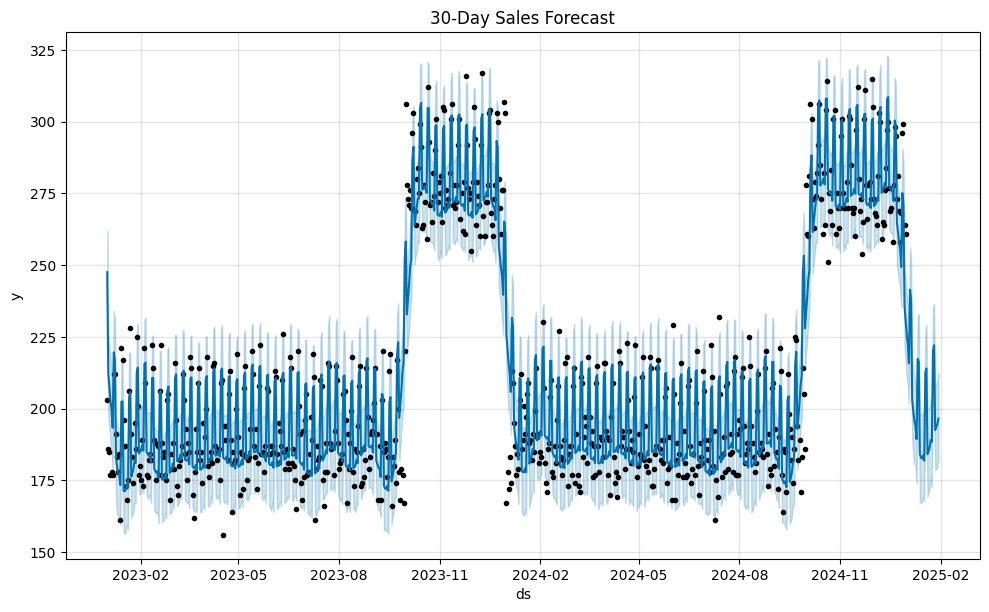

In [17]:
fig = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

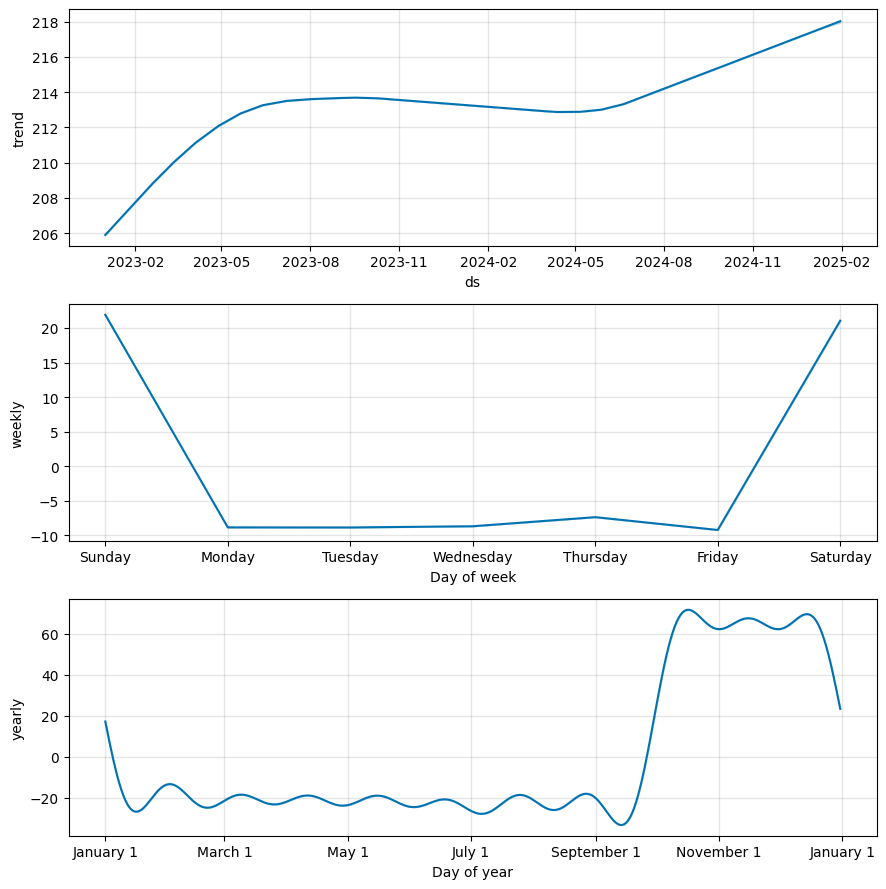

In [18]:
fig2 = model.plot_components(forecast)
plt.show()

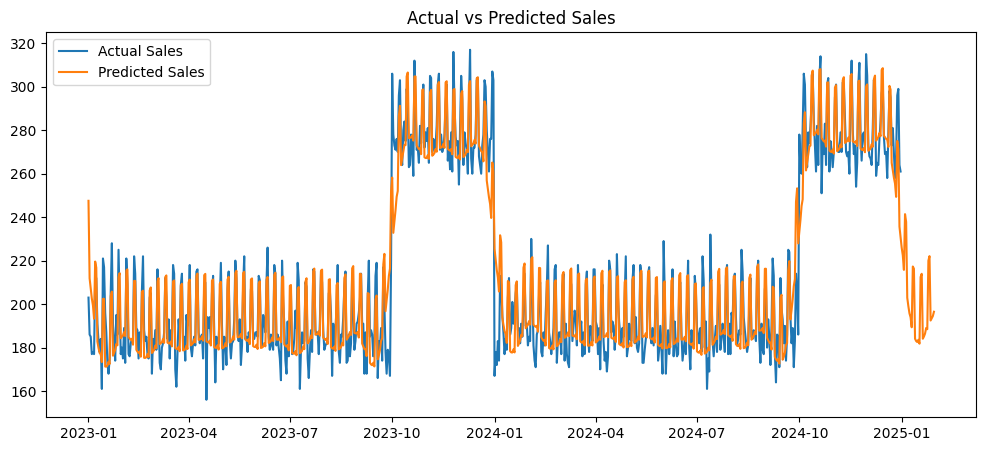

In [19]:
plt.figure(figsize=(12,5))

plt.plot(df_forecast['ds'], df_forecast['y'], label="Actual Sales")
plt.plot(forecast['ds'], forecast['yhat'], label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [20]:
from src.inventory import calculate_inventory_params

# Use daily sales
daily_sales = df.groupby('date')['sales'].sum()

avg, ss, rop = calculate_inventory_params(daily_sales)

print("Average Demand:", avg)
print("Safety Stock:", ss)
print("Reorder Point:", rop)

ModuleNotFoundError: No module named 'src'

In [21]:
import os
print(os.getcwd())

c:\Users\Sakshi\OneDrive\Desktop\Retail-Forecasting-System\notebooks


In [23]:
from src.inventory import calculate_inventory_params
print("Import successful")

Import successful


In [24]:
daily_sales = df.groupby('date')['sales'].sum()

avg, ss, rop = calculate_inventory_params(daily_sales)

print(avg, ss, rop)

213.17920656634746 181.882237733236 1674.1366836976683
